# Paper plots — KL-diag protagonist (Polar-LoRA)

Locked config: `kl-diag-polar-lora` · PolarExpress PE=8 · Nesterov · β₁=0.9 · δ=1e-4 · k=1 · curvature_beta=0.99 · precond_refresh_every=10 · **precond_method=gram_ns**. AdamW + iMuon baselines; σ=0.0017 noise floor.

In-flight runs render partially (`allow_partial=True`).

In [1]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
import matplotlib.pyplot as plt

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'lora_playground').is_dir())

from lora_playground.plotting import compare_variants_figure
from lora_playground.loader import load_runs

# Baselines + protagonist. AdamW MUST be a variant to render (target_label only annotates
# an already-loaded variant, it does not auto-load).
ADAMW = {'optimizer': 'adamw'}
PROTO = {'optimizer': 'kl-diag-polar-lora', 'cw_nesterov': True, 'polar_method': 'polar_express',
         'beta1': 0.9, 'precond_method': 'gram_ns',
         'cw_unpinned': False, 'cw_no_diag_curv': False}  # locked kl-diag config (excludes E2 ablation arms)
# E2 leave-one-out arms (same optimizer; disambiguated by the cw_* flags so they
# do NOT contaminate the protagonist panels above):
NOSHAMPOO = {**PROTO, 'cw_no_diag_curv': True}   # w/o curvature control: partner-Gram-only whitening (no curvature EMAs)
NOMAG     = {**PROTO, 'cw_unpinned': True, 'lora_init_b': 'symmetric'}  # w/o magnitude control (-pin): true-scale roots, no operator-norm rescale (curvature kept)

def _om(rank):  # common_where for Llama-openmath at a rank
    return dict(model_name='meta-llama/Llama-3.2-1B', lora_r=rank, data_dir=(lambda d: 'openmath' in str(d)))
def _has(where, rank):
    return len(load_runs(where={**where, **{k:v for k,v in _om(rank).items()}}, warn_cross_commit=False)) > 0
def ablation_panel(rank):
    """E2 leave-one-out at one rank; only arms with data render (allow_partial)."""
    arms = {'Polar-LoRA (kl-diag)': PROTO, 'w/o curvature control': NOSHAMPOO, 'w/o magnitude control': NOMAG,
            'w/o curvature+magnitude (LoRA-Muon step)': DOUBLE}
    arms = {k: v for k, v in arms.items() if _has(v, rank)}
    fig, _t, sdf = compare_variants_figure(
        arms, common_where=_om(rank), ref_label='Polar-LoRA (kl-diag)',
        logs_root=str(ROOT / 'logs'), sigma_ref=SIGMA, max_steps=9000,
        allow_partial=True, allow_custom_labels=True,
        suptitle=f'E2 ablation - Llama-3.2-1B openmath r{rank}')
    plt.show()
    return sdf
IMUON = {'optimizer': 'imuon-lora', 'max_steps': 9000}  # excludes the 1000-step lr pilot (ranking-only)
MUON = {'optimizer': 'muon-lora', 'max_steps': 9000}   # naive factor-Muon (pillar-1 arm); pilot excluded
DOUBLE = {**PROTO, 'cw_no_diag_curv': True, 'cw_unpinned': True, 'lora_init_b': 'symmetric', 'max_steps': 9000}  # both controls removed = the LoRA-Muon step (true-scale, no pin; symmetric init)
SIGMA = 0.0017  # AdamW noise-floor proxy

# The 8-cell E1 set (paper/e1_coverage_fill.md). data_key = substring matched on data_dir.
CELLS = [
    ('OLMo-2-1B opc r256',         'allenai/OLMo-2-0425-1B',     'opc',      256),
    ('Qwen2.5-1.5B opc r256',      'Qwen/Qwen2.5-1.5B',          'opc',      256),
    ('Llama-3.2-1B opc r256',      'meta-llama/Llama-3.2-1B',    'opc',      256),
    ('Llama-3-8B opc r256',        'meta-llama/Meta-Llama-3-8B', 'opc',      256),
    ('Qwen2.5-1.5B bengali r256',  'Qwen/Qwen2.5-1.5B',          'bengali',  256),
    ('Llama-3.2-1B openmath r16',  'meta-llama/Llama-3.2-1B',    'openmath',   16),
    ('Llama-3.2-1B openmath r32',  'meta-llama/Llama-3.2-1B',    'openmath',   32),
    ('Llama-3.2-1B openmath r64',  'meta-llama/Llama-3.2-1B',    'openmath',  64),
    ('Llama-3.2-1B openmath r128', 'meta-llama/Llama-3.2-1B',    'openmath', 128),
    ('Llama-3.2-1B openmath r256', 'meta-llama/Llama-3.2-1B',    'openmath', 256),
]

def panel(name, model, key, rank):
    """AdamW vs Polar-LoRA (kl-diag) vs iMuon at one cell; Δ vs AdamW in σ-units."""
    common = dict(model_name=model, lora_r=rank, data_dir=(lambda d, k=key: k in str(d)))
    fig, _tdf, sdf = compare_variants_figure(
        {'AdamW': ADAMW, 'Polar-LoRA (kl-diag)': PROTO, 'iMuon': IMUON, 'Muon (naive)': MUON, 'w/o curvature+magnitude (LoRA-Muon step)': DOUBLE},
        common_where=common, ref_label='AdamW',
        logs_root=str(ROOT / 'logs'), sigma_ref=SIGMA, max_steps=9000,
        allow_partial=True, allow_custom_labels=True, target_label='AdamW',
        suptitle=name,
    )
    plt.show()
    return sdf

## Per-cell panels — AdamW vs Polar-LoRA (kl-diag) vs iMuon vs naive factor-Muon vs the double-ablation (w/o curvature+magnitude); baseline arms render in any panel where their runs exist (in-flight runs show from first eval)

### 1. OLMo-2-1B opc r256

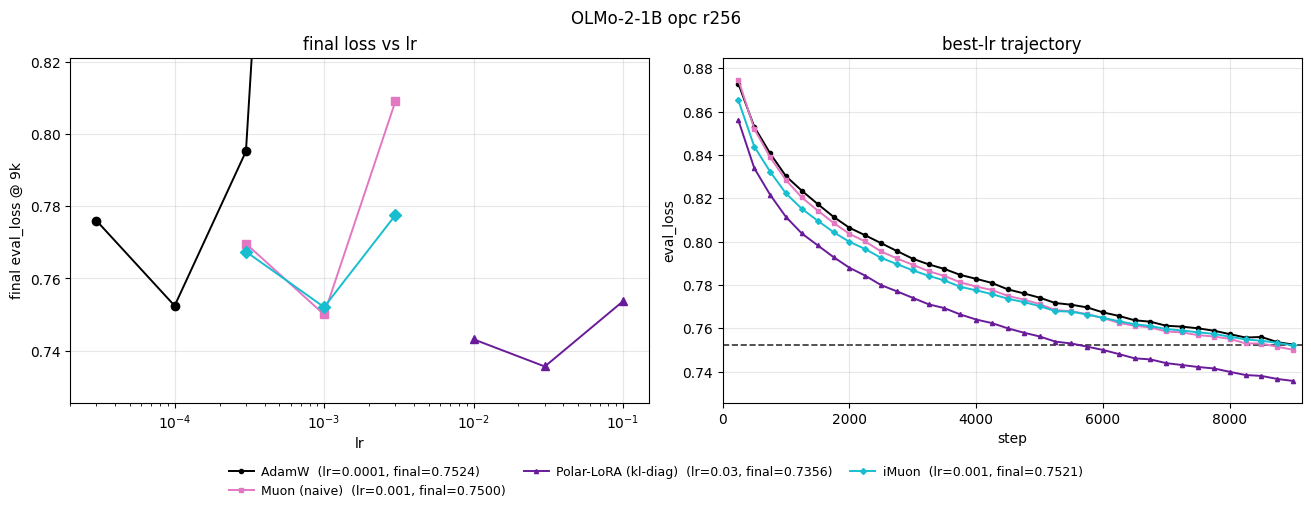

,variant,best_lr,final,delta,delta_sigma
0,AdamW,0.0001,0.752439,NaN,NaN
1,Muon (naive),0.0010,0.750033,-0.002406,-1.415284
2,Polar-LoRA (kl-diag),0.0300,0.735641,-0.016797,-9.880739
3,iMuon,0.0010,0.752073,-0.000365,-0.214891


In [2]:
panel('OLMo-2-1B opc r256', 'allenai/OLMo-2-0425-1B', 'opc', 256)

### 2. Qwen2.5-1.5B opc r256

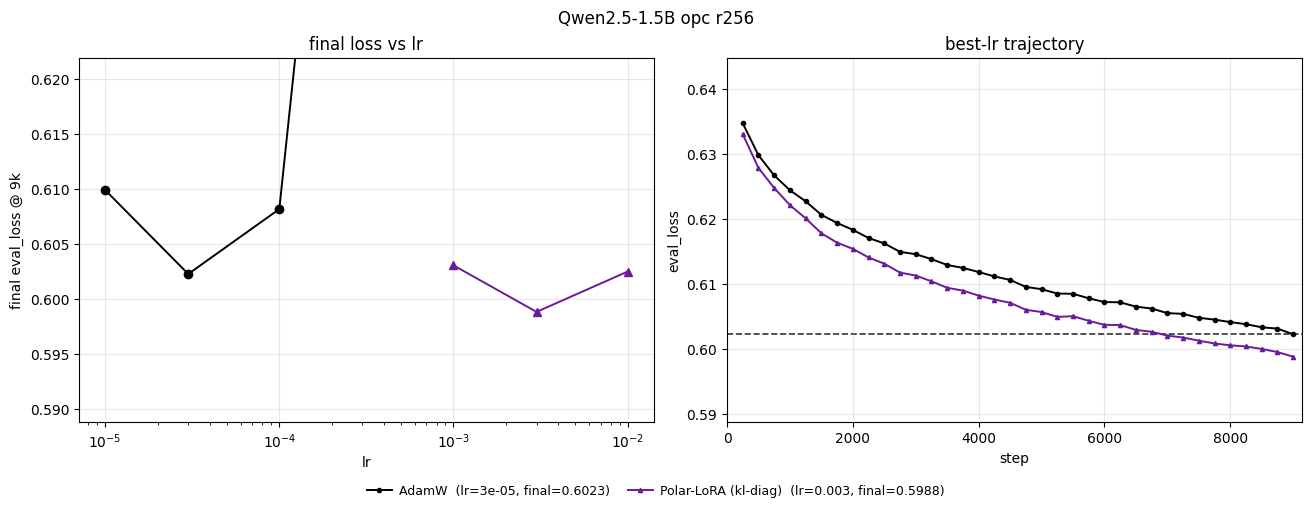

,variant,best_lr,final,delta,delta_sigma
0,AdamW,0.00003,0.602292,NaN,NaN
1,Polar-LoRA (kl-diag),0.00300,0.598845,-0.003447,-2.027497


In [3]:
panel('Qwen2.5-1.5B opc r256', 'Qwen/Qwen2.5-1.5B', 'opc', 256)

### 3. Llama-3.2-1B opc r256

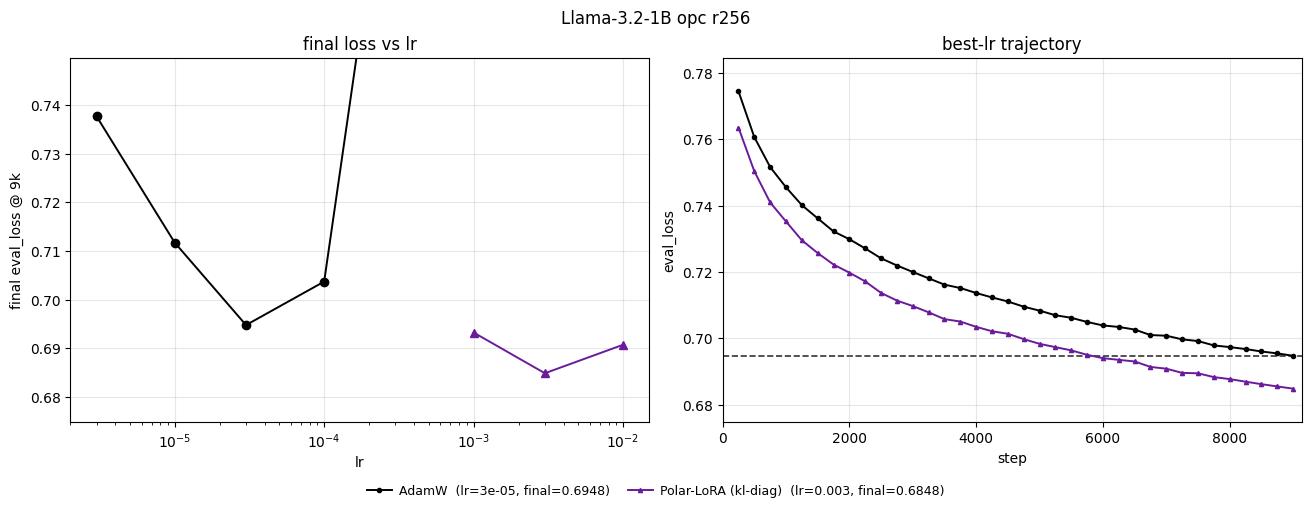

,variant,best_lr,final,delta,delta_sigma
0,AdamW,0.00003,0.694754,NaN,NaN
1,Polar-LoRA (kl-diag),0.00300,0.684849,-0.009905,-5.826258


In [4]:
panel('Llama-3.2-1B opc r256', 'meta-llama/Llama-3.2-1B', 'opc', 256)

### 4. Llama-3-8B opc r256

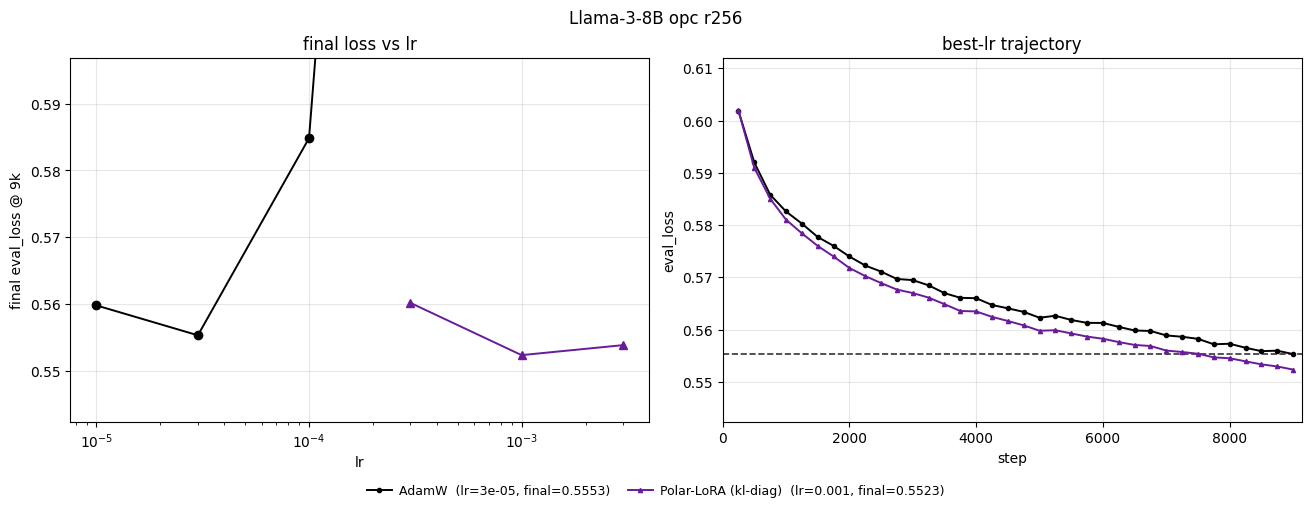

,variant,best_lr,final,delta,delta_sigma
0,AdamW,0.00003,0.555303,NaN,NaN
1,Polar-LoRA (kl-diag),0.00100,0.552333,-0.00297,-1.747025


In [5]:
panel('Llama-3-8B opc r256', 'meta-llama/Meta-Llama-3-8B', 'opc', 256)

### 5. Qwen2.5-1.5B bengali r256  (OOD pair vs cell 2)

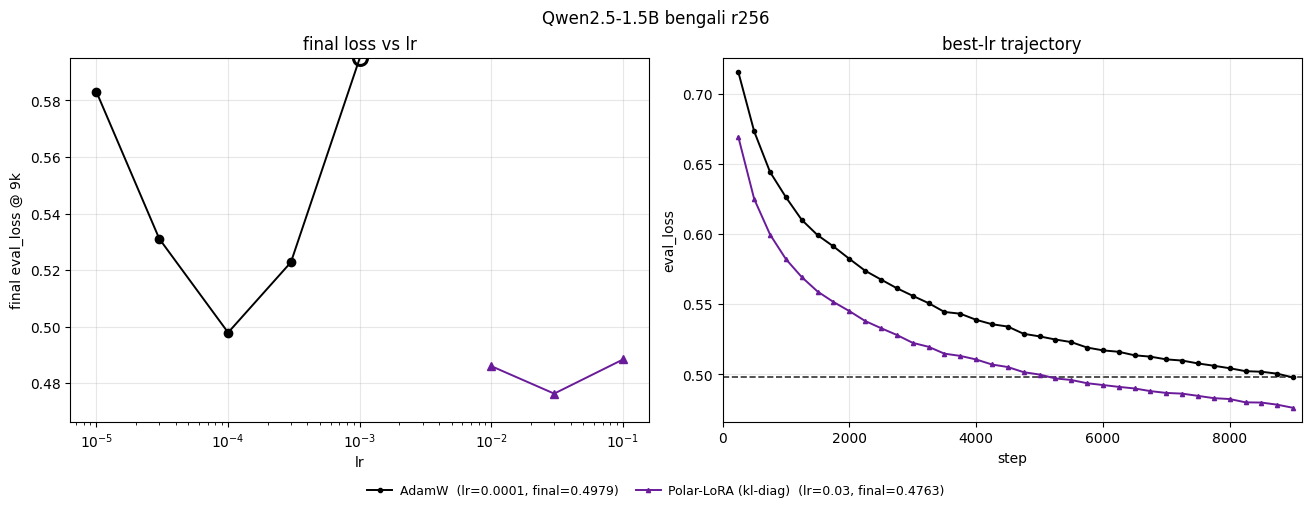

,variant,best_lr,final,delta,delta_sigma
0,AdamW,0.0001,0.497858,NaN,NaN
1,Polar-LoRA (kl-diag),0.0300,0.476251,-0.021607,-12.710198


In [6]:
panel('Qwen2.5-1.5B bengali r256', 'Qwen/Qwen2.5-1.5B', 'bengali', 256)

### Llama-3.2-1B openmath r16  (rank ladder — low rank, common LoRA regime)

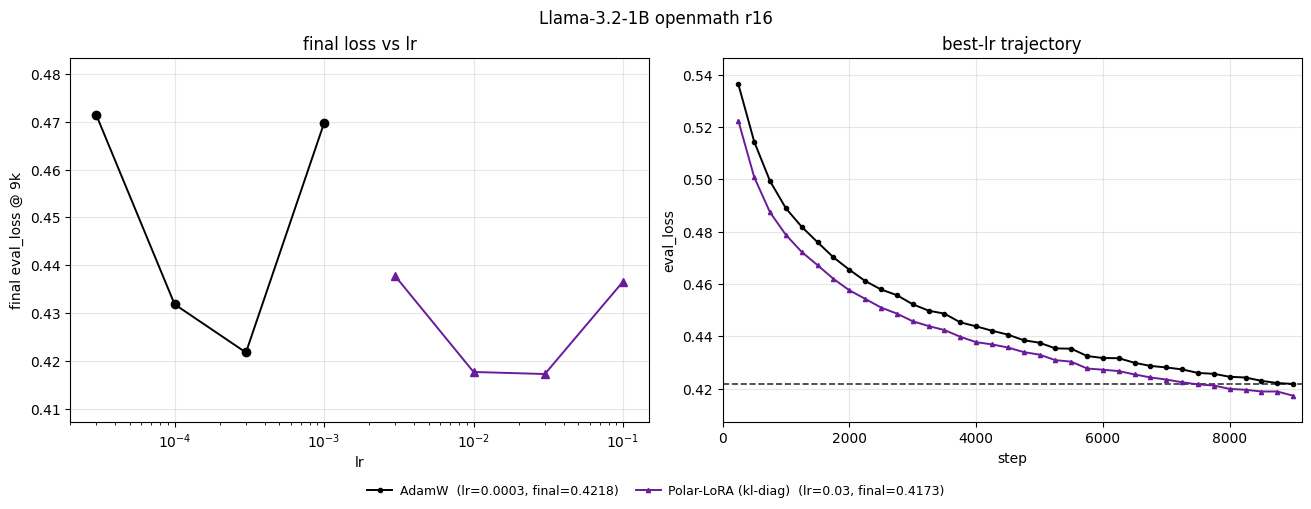

,variant,best_lr,final,delta,delta_sigma
0,AdamW,0.0003,0.421763,NaN,NaN
1,Polar-LoRA (kl-diag),0.0300,0.417263,-0.0045,-2.647324


In [7]:
panel('Llama-3.2-1B openmath r16', 'meta-llama/Llama-3.2-1B', 'openmath', 16)

### Llama-3.2-1B openmath r32  (rank ladder — low rank)

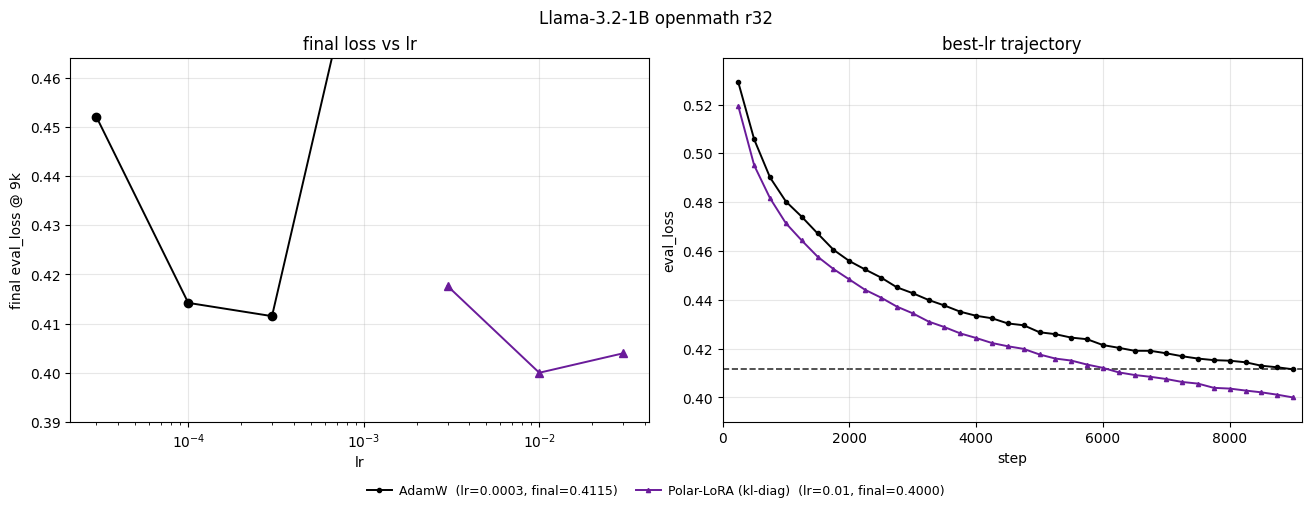

,variant,best_lr,final,delta,delta_sigma
0,AdamW,0.0003,0.411517,NaN,NaN
1,Polar-LoRA (kl-diag),0.0100,0.399991,-0.011526,-6.779981


In [8]:
panel('Llama-3.2-1B openmath r32', 'meta-llama/Llama-3.2-1B', 'openmath', 32)

### 6. Llama-3.2-1B openmath r64  (rank ladder)

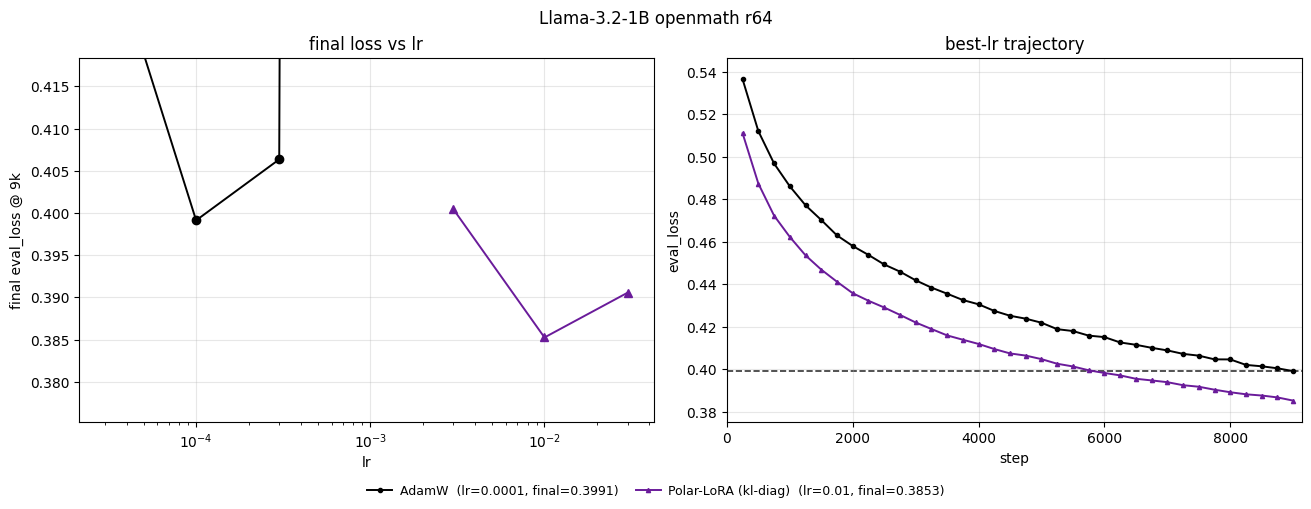

,variant,best_lr,final,delta,delta_sigma
0,AdamW,0.0001,0.399128,NaN,NaN
1,Polar-LoRA (kl-diag),0.0100,0.385254,-0.013874,-8.160944


In [9]:
panel('Llama-3.2-1B openmath r64', 'meta-llama/Llama-3.2-1B', 'openmath', 64)

### 7. Llama-3.2-1B openmath r128  (rank ladder)

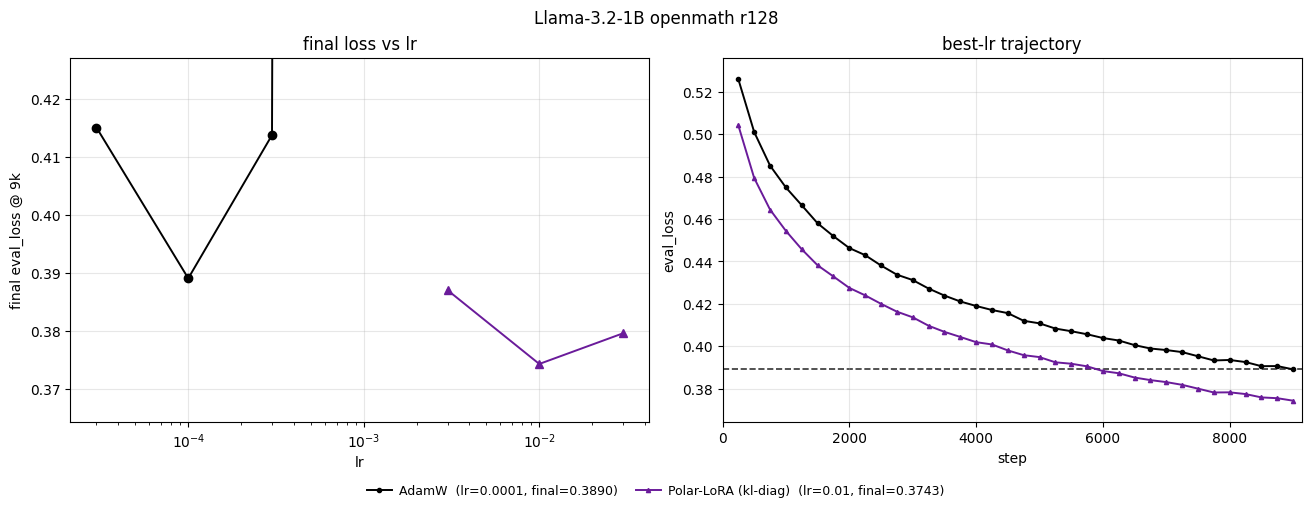

,variant,best_lr,final,delta,delta_sigma
0,AdamW,0.0001,0.389044,NaN,NaN
1,Polar-LoRA (kl-diag),0.0100,0.374259,-0.014785,-8.696915


In [10]:
panel('Llama-3.2-1B openmath r128', 'meta-llama/Llama-3.2-1B', 'openmath', 128)

### 8. Llama-3.2-1B openmath r256  (rank ladder)

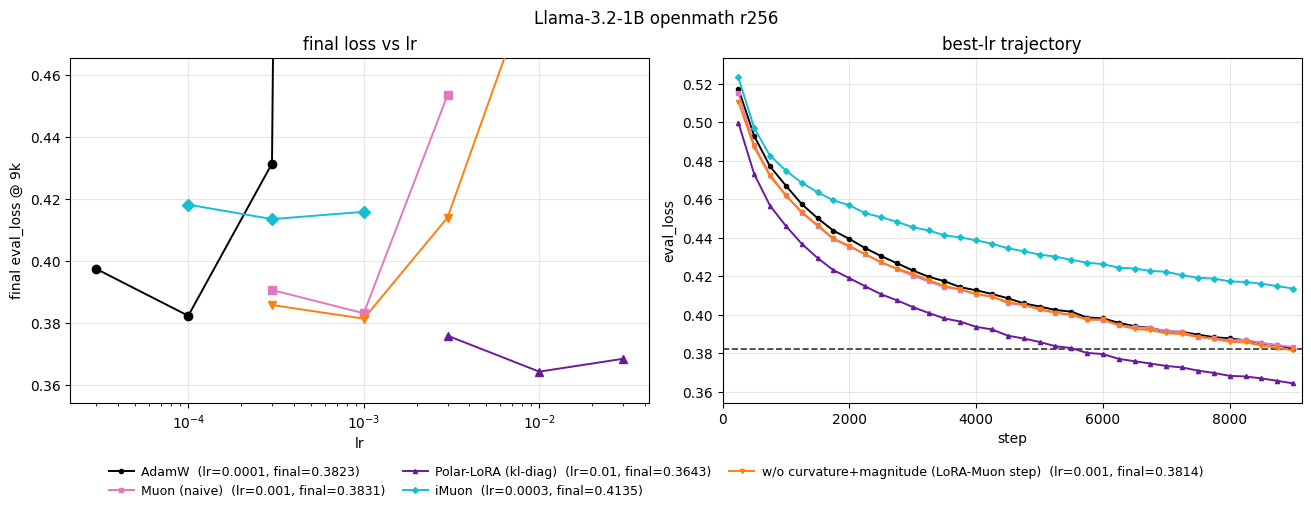

,variant,best_lr,final,delta,delta_sigma
0,AdamW,0.0001,0.382301,NaN,NaN
1,Muon (naive),0.0010,0.383107,0.000807,0.474588
2,Polar-LoRA (kl-diag),0.0100,0.364270,-0.018031,-10.606193
3,iMuon,0.0003,0.413505,0.031204,18.355461
4,w/o curvature+magnitude (LoRA-Muon step),0.0010,0.381368,-0.000933,-0.548812


In [11]:
panel('Llama-3.2-1B openmath r256', 'meta-llama/Llama-3.2-1B', 'openmath', 256)

## E2 ablation — Llama-3.2-1B openmath, per rank (leave-one-out)

One panel per rank. Arms: **Polar-LoRA (kl-diag)** vs **w/o curvature control** (drop the
curvature EMAs → partner-Gram-only whitening; the novelty over the iMuon family) vs
**w/o magnitude control** (`cw_unpinned`: remove the operator-norm magnitude rule → true-scale,
no pin) vs **w/o curvature+magnitude (LoRA-Muon step)**. Δ vs Polar-LoRA (kl-diag) in σ-units,
step-matched (`allow_partial`). The w/o-curvature arm runs at r256 only (the canonical rank).
Polar is *not* ablated (cited to the spectral-method literature).

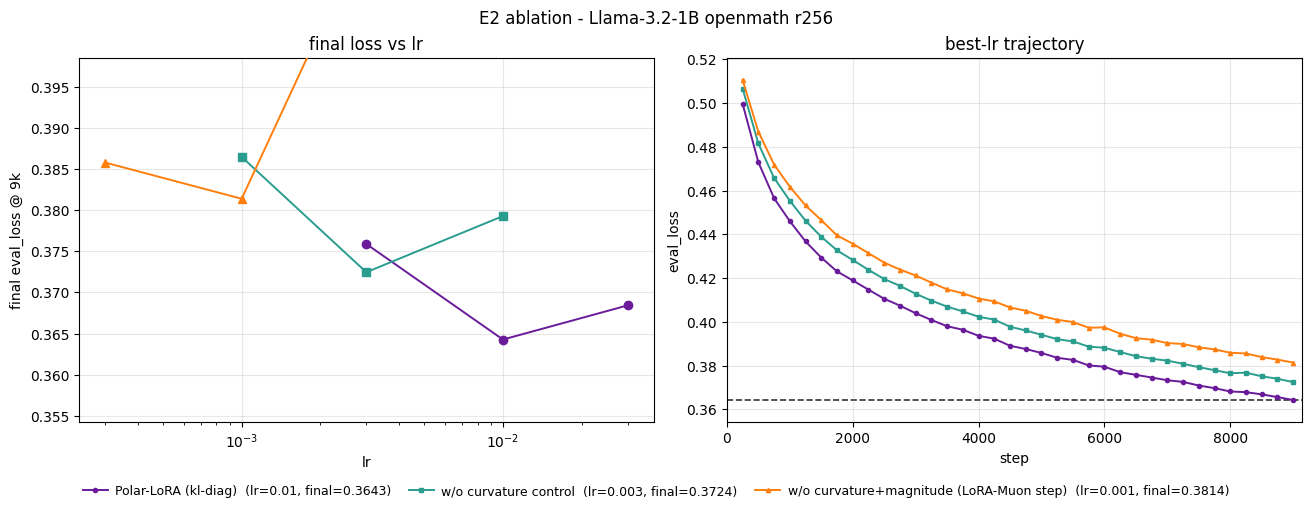

,variant,best_lr,final,delta,delta_sigma
0,Polar-LoRA (kl-diag),0.010,0.364270,NaN,NaN
1,w/o curvature control,0.003,0.372446,0.008176,4.809154
2,w/o curvature+magnitude (LoRA-Muon step),0.001,0.381368,0.017098,10.057381


In [12]:
ablation_panel(256)

## Per-rank final loss vs lr — Llama-3.2-1B openmath, all ranks (r16/r32/r64/r128/r256)

Two side-by-side panels, **Polar-LoRA (kl-diag)** and **AdamW**. For each, final eval loss
(9000 steps) vs lr, one curve per rank (color = rank, reversed viridis). Shared y-axis; x is
each optimizer's own lr grid. Final-step runs only (partial runs skipped). Exploratory all-ranks
view; the clean $r\ge32$ transfer figure (r16 excluded) lives in `paper_figs.ipynb`.

3 high-lr point(s) above y-window (divergence), clipped at 0.500


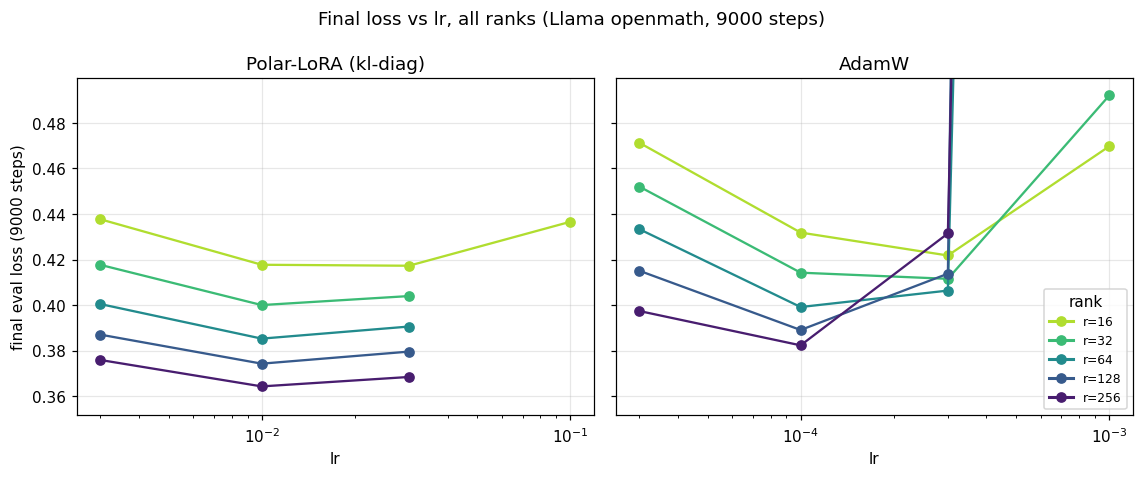

In [ ]:
# Final eval loss (9000 steps) vs lr, ALL ranks (Llama openmath). Two side-by-side panels:
# Polar-LoRA (kl-diag) | AdamW. Color = rank (reversed viridis: light = low rank, dark = high).
# Only runs that reached 9000 steps count (a partial run would plot an early-step loss against
# final losses). Exploratory all-ranks view; the clean r>=32 transfer figure lives in paper_figs.ipynb
# (r16's flat basin top is under-resolved). Shared y, windowed to the converged band (high-lr
# divergence runs off the top of the panel; clipped count printed).
import numpy as np
import matplotlib.cm as cm
from matplotlib.lines import Line2D
RANKS=[16,32,64,128,256]; HORIZON=9000
RANK_COLOR={r:c for r,c in zip(RANKS, cm.viridis_r(np.linspace(0.12,0.92,len(RANKS))))}
def _final_by_lr(where, rank):
    runs=load_runs(where={**where,'lora_r':rank,'model_name':'meta-llama/Llama-3.2-1B',
                          'data_dir':(lambda d:'openmath' in str(d))}, warn_cross_commit=False)
    out={}
    for cfg,evs in runs:
        ev=[(e['step'],e['eval_loss']) for e in (evs or []) if e.get('eval_loss') is not None]
        if not ev or ev[-1][0] < HORIZON: continue   # final losses only (skip partial runs)
        lr=float(cfg.get('lr')); out[lr]=min(out.get(lr,9e9), ev[-1][1])
    return dict(sorted(out.items()))
_PANELS=[('Polar-LoRA (kl-diag)',PROTO),('AdamW',ADAMW)]
panel_data=[]; allv=[]; empty=[]
for label,where in _PANELS:
    dd={rank:_final_by_lr(where,rank) for rank in RANKS}
    panel_data.append((label,dd))
    for rank,d in dd.items():
        if d: allv+=list(d.values())
        else: empty.append(f'{label} r{rank}')
# robust y-window: keep the converged band readable, let high-lr divergence run off-panel
med=float(np.median(allv)); conv=[v for v in allv if v < 3*med]
lo,hi=min(allv),max(conv); rng=hi-lo
ylo,yhi=lo-0.10*rng, hi+0.06*rng   # extra bottom pad so the lowest (r256) markers clear the axis
fig,axes=plt.subplots(1,len(_PANELS),figsize=(10.5,4.4),sharey=True)
for ax,(label,dd) in zip(axes,panel_data):
    for rank in RANKS:
        d=dd[rank]
        if d: ax.plot(list(d),list(d.values()),'o-',color=RANK_COLOR[rank],label=f'r={rank}')
    ax.set_xscale('log'); ax.set_xlabel('lr'); ax.set_title(label); ax.grid(alpha=.3)
    ax.set_ylim(ylo,yhi)
axes[0].set_ylabel('final eval loss (9000 steps)')
h_rank=[Line2D([],[],color=RANK_COLOR[r],marker='o',lw=2,label=f'r={r}') for r in RANKS]
axes[-1].legend(handles=h_rank,title='rank',loc='best',fontsize=8)
fig.suptitle('Final loss vs lr, all ranks (Llama openmath, 9000 steps)')
nclip=sum(v>yhi for v in allv)
if nclip: print(f'{nclip} high-lr point(s) above y-window (divergence), clipped at {yhi:.3f}')
if empty: print('NO 9000-step data (arm not run yet):', ', '.join(empty))
plt.tight_layout(); plt.show()

## Gauge diagnostics (exploratory) — openmath r256, per-pair over 112 LoRA pairs

Rougher/denser than `paper_figs.fig_gauge`: raw $\sigma_{max}(A)$, $\sigma_{max}(B)$, the per-pair ratio, BaLoRA residual, and factor norms, both arms. Reads the gauge diagnostic runs' logs directly; default palette. Populates as `gauge_kldiag_r256_bw` / `gauge_loramuon_r256_bw` run.

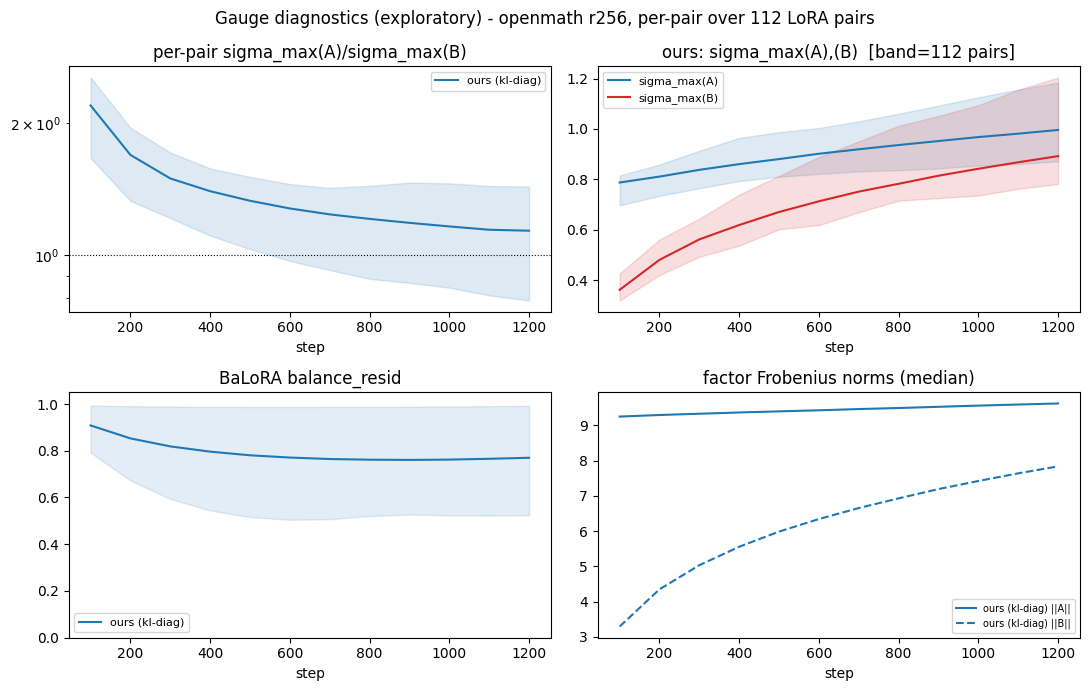

In [14]:
# Exploratory gauge diagnostics: read the gauge runs' per-step optim_step events directly
# (per-pair min/median/max over the 112 LoRA pairs). Rougher than the polished paper_figs version.
import json, glob
import numpy as np
import matplotlib.pyplot as plt
def gtraj(group):
    for f in sorted(glob.glob(str(ROOT/'logs'/group/'run_info'/'logs'/'log_*.out'))):
        rows=[json.loads(l) for l in open(f) if '"balance_resid_median"' in l]
        rows=[r for r in rows if r.get('event')=='optim_step']
        if rows:
            g=lambda k: np.array([r.get(k,np.nan) for r in rows], float)
            return {k:g(k) for k in ('step','sigma_max_A_median','sigma_max_A_min','sigma_max_A_max',
                'sigma_max_B_median','sigma_max_B_min','sigma_max_B_max','sigma_ratio_median',
                'sigma_ratio_min','sigma_ratio_max','balance_resid_median','balance_resid_min',
                'balance_resid_max','norm_A_median','norm_B_median')}
    return None
ARMS={'ours (kl-diag)':'gauge_kldiag_r256_bw','LoRA-Muon step':'gauge_loramuon_r256_bw'}
D={k:gtraj(v) for k,v in ARMS.items()}
fig,ax=plt.subplots(2,2,figsize=(11,7))
for i,(lab,d) in enumerate(D.items()):       # per-pair sigma ratio
    if d is None: continue
    ax[0,0].fill_between(d['step'],d['sigma_ratio_min'],d['sigma_ratio_max'],color=f'C{i}',alpha=.15)
    ax[0,0].plot(d['step'],d['sigma_ratio_median'],f'C{i}',label=lab)
ax[0,0].axhline(1,color='k',ls=':',lw=.8); ax[0,0].set_yscale('log')
ax[0,0].set_title('per-pair sigma_max(A)/sigma_max(B)'); ax[0,0].set_xlabel('step'); ax[0,0].legend(fontsize=8)
d=D['ours (kl-diag)']                          # sigma_max A,B for ours (convergence)
if d is not None:
    ax[0,1].fill_between(d['step'],d['sigma_max_A_min'],d['sigma_max_A_max'],color='C0',alpha=.15)
    ax[0,1].plot(d['step'],d['sigma_max_A_median'],'C0',label='sigma_max(A)')
    ax[0,1].fill_between(d['step'],d['sigma_max_B_min'],d['sigma_max_B_max'],color='C3',alpha=.15)
    ax[0,1].plot(d['step'],d['sigma_max_B_median'],'C3',label='sigma_max(B)')
ax[0,1].set_title('ours: sigma_max(A),(B)  [band=112 pairs]'); ax[0,1].set_xlabel('step'); ax[0,1].legend(fontsize=8)
for i,(lab,d) in enumerate(D.items()):       # balance_resid
    if d is None: continue
    ax[1,0].fill_between(d['step'],d['balance_resid_min'],d['balance_resid_max'],color=f'C{i}',alpha=.13)
    ax[1,0].plot(d['step'],d['balance_resid_median'],f'C{i}',label=lab)
ax[1,0].axhline(0,color='k',ls=':',lw=.8); ax[1,0].set_ylim(0,1.05)
ax[1,0].set_title('BaLoRA balance_resid'); ax[1,0].set_xlabel('step'); ax[1,0].legend(fontsize=8)
for i,(lab,d) in enumerate(D.items()):       # factor norms
    if d is None: continue
    ax[1,1].plot(d['step'],d['norm_A_median'],f'C{i}',label=f'{lab} ||A||')
    ax[1,1].plot(d['step'],d['norm_B_median'],f'C{i}',ls='--',label=f'{lab} ||B||')
ax[1,1].set_title('factor Frobenius norms (median)'); ax[1,1].set_xlabel('step'); ax[1,1].legend(fontsize=7)
fig.suptitle('Gauge diagnostics (exploratory) - openmath r256, per-pair over 112 LoRA pairs')
plt.tight_layout(); plt.show()